# Causal Analysis for Trading Decisions: A Momentum Case Study

**Chapter 15: Causal Estimation with ML**
**Docker image**: `ml4t`

This notebook demonstrates how causal inference methodology applies to trading
research, with honest assessment of what it can and cannot prove.

**Book Reference**: Chapter 15, §15.4 (Isolating Factor Effects with DML)

**The Question**: Does momentum have a causal effect on forward returns, and
does this effect vary by volatility regime?

**Methodological Approach**:
1. Define a clear train/test split (no look-ahead bias)
2. Estimate causal effects using only training data
3. Apply regime-conditional allocation to held-out test period
4. Compare to naive baseline and simple alternatives
5. Include transaction costs

**Key Insight**: We demonstrate the *workflow* of causal-informed trading,
while being honest that in-sample improvements often don't persist out-of-sample.

**Learning Outcomes**:
- Apply proper train/test methodology to causal trading research
- Understand the difference between in-sample fit and out-of-sample value
- See how regime-conditional effects (CATE) inform allocation decisions

**Prerequisites**: [`03_econml_dml`](03_econml_dml.ipynb) for DML methodology;
ETF feature data from Ch8 pipeline

## Causal Design Contract

| Element                   | This notebook                                                                                |
|---------------------------|----------------------------------------------------------------------------------------------|
| Unit                      | ETF-date row from the ETF modeling panel                                                     |
| Treatment                 | `skip_recent_6_1` momentum (continuous)                                                       |
| Outcome                   | `fwd_ret_21d` - 21-day forward return                                                         |
| Controls (W)              | `vol_21d`, `vol_63d`, `vol_126d`, `yield_curve_slope`                                         |
| Effect modifiers (X)      | `market_volatility` (SPY 63-day vol) + high-/low-vol regime indicators, via CausalForestDML   |
| Identification assumption | Selection on observables given the four controls; CATE varies smoothly with realized vol     |
| Main failure modes        | Unobserved confounding; CATE generalization failure out of sample; trading cost erosion       |
| Estimand                  | ATE and regime-conditional CATE from CausalForestDML; downstream trading rule scales position by sign-of-CATE × magnitude |

## 1. Setup and Configuration

In [1]:
"""Causal Analysis for Trading Decisions - apply DML-based causal estimates to a momentum trading strategy."""

import datetime
import json
import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor

import utils.style  # noqa: F401  # registers + activates the ml4t Plotly template
from utils.modeling import load_modeling_dataset
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

# Try to import EconML
try:
    from econml.dml import CausalForestDML, LinearDML

    ECONML_AVAILABLE = True
    print("EconML available")
except Exception as e:
    print(f"EconML unavailable ({type(e).__name__}: {e})")
    print("Install/fix with: uv pip install econml")
    ECONML_AVAILABLE = False

EconML available


In [2]:
# Configuration
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = "fwd_ret_21d"
MAX_SYMBOLS = 0
SEED = 42
RETRAIN = False  # Set True to force retraining; False loads cached artifacts
MAX_SAMPLES = 0

# Momentum parameters
FORWARD_DAYS = 21  # Forward return horizon (matches label)

# Strategy parameters
N_QUANTILES = 5  # Quintile portfolios

# Transaction Costs: 10 bps round-trip for liquid ETFs
TRANSACTION_COST_BPS = 10

# DML parameters
CV_FOLDS = 5
RUN_TAG = "full"  # Suffix for cached artifacts
SYMBOL_SUBSET = []
DML_NUISANCE_ESTIMATORS = 100
CF_MODEL_ESTIMATORS = 100
CF_FOREST_ESTIMATORS = 500

In [3]:
set_global_seeds(SEED)

CACHE_TAG = RUN_TAG
OUTPUT_DIR = get_output_dir(15, "momentum_causal_trading")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DML_CACHE_PATH = OUTPUT_DIR / f"dml_artifacts_{CASE_STUDY_ID}_{PRIMARY_LABEL}_{CACHE_TAG}.json"
RESULTS_PATH = (
    OUTPUT_DIR / f"momentum_causal_trading_{CASE_STUDY_ID}_{PRIMARY_LABEL}_{CACHE_TAG}.json"
)

print("Momentum Causal Trading Configuration:")
print(f"  Forward: {FORWARD_DAYS} days")
print(f"  Transaction cost: {TRANSACTION_COST_BPS} bps")
print(f"  Run tag: {RUN_TAG}")
print(f"  Retrain DML artifacts: {RETRAIN}")

Momentum Causal Trading Configuration:
  Forward: 21 days
  Transaction cost: 10 bps
  Run tag: full
  Retrain DML artifacts: False


## 2. Load ETF Features from Modeling Pipeline

We use `load_modeling_dataset()` to load pre-computed momentum features (Ch8),
temporal features (Ch9), and labels from the case study pipeline.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
splits = mds.splits

# Key columns
treatment_col = "skip_recent_6_1"  # 6-month skip-recent momentum
outcome_col = mds.label_col
date_col = mds.date_col

# We need momentum, volatility, and regime for the trading strategy
needed_cols = [
    date_col,
    "symbol",
    treatment_col,
    outcome_col,
    "vol_63d",
    "regime",
    "yield_curve_slope",
    "vol_21d",
    "vol_126d",
]

available = set(mds.dataset.columns)
analysis_cols = [c for c in needed_cols if c in available]

# Convert to pandas for downstream analysis
features_df = mds.dataset.select(analysis_cols).drop_nulls().sort(date_col)
print(
    f"Feature dataset: {features_df.shape[0]:,} observations across {features_df['symbol'].n_unique()} ETFs"
)
print(f"Date range: {features_df[date_col].min()} to {features_df[date_col].max()}")

# Optional asset subset for faster runs
if SYMBOL_SUBSET:
    features_df = features_df.filter(pl.col("symbol").is_in(SYMBOL_SUBSET))
    print(f"Reduced to {features_df['symbol'].n_unique()} assets")

Feature dataset: 394,233 observations across 99 ETFs
Date range: 2007-01-03 to 2025-12-01


### 2.1 Define Market Volatility Regime

We define regime based on market-wide volatility (SPY as proxy).
This is a potential confounder OR effect modifier.

In [5]:
def assign_volatility_regime(features_df, date_col, splits):
    """Assign market volatility regime labels using pre-holdout thresholds."""
    if "regime" in features_df.columns:
        # Regime already computed in Ch8 features
        # Map numeric regime to string labels for strategy logic
        # Use SPY when available; otherwise fall back to cross-sectional median volatility.
        if features_df.filter(pl.col("symbol") == "SPY").height > 0:
            market_vol = (
                features_df.filter(pl.col("symbol") == "SPY")
                .select([date_col, "vol_63d"])
                .rename({"vol_63d": "market_volatility"})
            )
            market_vol_source = "SPY"
        else:
            market_vol = (
                features_df.group_by(date_col)
                .agg(pl.col("vol_63d").median().alias("market_volatility"))
                .sort(date_col)
            )
            market_vol_source = "cross-sectional median"

        # `splits` is reverse-chronological; splits[0] is the most recent fold.
        holdout_boundary = datetime.date.fromisoformat(str(splits[0]["val_start"])[:10])

        # Regime thresholds from pre-holdout data only
        train_market_vol = market_vol.filter(pl.col(date_col) < holdout_boundary)
        vol_values = train_market_vol["market_volatility"].drop_nulls().to_numpy()
        if len(vol_values) == 0:
            vol_values = (
                features_df.filter(pl.col(date_col) < holdout_boundary)["vol_63d"]
                .drop_nulls()
                .to_numpy()
            )
            market_vol_source = f"{market_vol_source} fallback"

        low_thresh = np.percentile(vol_values, 33)
        high_thresh = np.percentile(vol_values, 67)

        print(f"Regime thresholds (source={market_vol_source}):")
        print(f"  Low volatility: < {low_thresh:.2%}")
        print(f"  High volatility: > {high_thresh:.2%}")

        market_vol = market_vol.with_columns(
            pl.when(pl.col("market_volatility") < low_thresh)
            .then(pl.lit("low_vol"))
            .when(pl.col("market_volatility") > high_thresh)
            .then(pl.lit("high_vol"))
            .otherwise(pl.lit("mid_vol"))
            .alias("regime_label")
        )

        features_df = features_df.join(
            market_vol.select([date_col, "market_volatility", "regime_label"]),
            on=date_col,
            how="inner",
        )
    else:
        # Fallback: compute from vol_63d
        features_df = features_df.with_columns(
            pl.lit("mid_vol").alias("regime_label"),
            pl.col("vol_63d").alias("market_volatility"),
        )
    return features_df


features_df = assign_volatility_regime(features_df, date_col, splits)

Regime thresholds (source=SPY):
  Low volatility: < 11.85%
  High volatility: > 17.73%


### 2.2 Train/Test Split

We use the walk-forward splits from the modeling pipeline.
Training: all folds except last validation period.
Test: last validation period (most recent data).

In [6]:
# `mds.splits` is reverse-chronological; splits[0] is the most recent fold.
TRAIN_END = splits[0]["train_end"]
TEST_START = splits[0]["val_start"]

_train_end = datetime.date.fromisoformat(str(TRAIN_END)[:10])
_test_start = datetime.date.fromisoformat(str(TEST_START)[:10])
train_df = features_df.filter(pl.col(date_col) <= _train_end)
test_df = features_df.filter(pl.col(date_col) >= _test_start)

if MAX_SAMPLES and train_df.height > MAX_SAMPLES:
    print(f"Taking most recent {MAX_SAMPLES:,} training rows from {train_df.height:,}")
    train_df = train_df.tail(MAX_SAMPLES)

assert _train_end < _test_start, f"Train end {_train_end} must precede test start {_test_start}"
assert train_df[date_col].max() < test_df[date_col].min(), (
    "Train and test date ranges overlap - split logic is broken"
)

print(f"\nTrain set: {len(train_df):,} observations")
print(f"Test set:  {len(test_df):,} observations")
print(f"Train end: {TRAIN_END}")
print(f"Test start: {TEST_START}")

print("\nRegime distribution (TRAIN):")
print(train_df.group_by("regime_label").agg(pl.len().alias("count")))

print("\nRegime distribution (HOLDOUT):")
print(test_df.group_by("regime_label").agg(pl.len().alias("count")))


Train set: 323,315 observations
Test set:  68,923 observations
Train end: 2022-11-28 00:00:00
Test start: 2022-12-29 00:00:00

Regime distribution (TRAIN):
shape: (3, 2)
┌──────────────┬────────┐
│ regime_label ┆ count  │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ low_vol      ┆ 113421 │
│ high_vol     ┆ 99842  │
│ mid_vol      ┆ 110052 │
└──────────────┴────────┘

Regime distribution (HOLDOUT):
shape: (3, 2)
┌──────────────┬───────┐
│ regime_label ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ low_vol      ┆ 27300 │
│ mid_vol      ┆ 31653 │
│ high_vol     ┆ 9970  │
└──────────────┴───────┘


## 3. Training Period: Estimate Causal Effects

We fit all causal models on the TRAINING data only. These estimates will
then be applied to the held-out test period.

In [7]:
print("\n" + "=" * 60)
print("TRAINING PERIOD ANALYSIS")
print("=" * 60)

train_pd = train_df.to_pandas()

# Overall IC (Information Coefficient) - training period
train_ic = stats.spearmanr(train_pd[treatment_col], train_pd[outcome_col])[0]
print(f"\nMomentum IC (train): {train_ic:.4f}")

# IC by regime - training period
print("\nIC by Regime (train):")
for regime_label in ["low_vol", "mid_vol", "high_vol"]:
    regime_data = train_pd[train_pd["regime_label"] == regime_label]
    if len(regime_data) > 50:
        ic = stats.spearmanr(regime_data[treatment_col], regime_data[outcome_col])[0]
        print(f"  {regime_label}: IC = {ic:.4f} (n={len(regime_data):,})")


TRAINING PERIOD ANALYSIS

Momentum IC (train): 0.0226

IC by Regime (train):
  low_vol: IC = 0.0673 (n=113,421)


  mid_vol: IC = 0.1092 (n=110,052)


  high_vol: IC = -0.0361 (n=99,842)


### 3.1 Causal Effect Estimation with DML

We estimate:
1. Average Treatment Effect (ATE) - overall momentum effect
2. Conditional Average Treatment Effect (CATE) by regime

In [8]:
# Prepare training arrays for DML
ate = None
ate_ci = (np.nan, np.nan)
naive_estimate = None
cate_by_regime = None
cate_std_by_regime = None

if ECONML_AVAILABLE:
    print("\n=== CAUSAL ANALYSIS (DML) ON TRAINING DATA ===\n")
    train_pd["regime_high"] = (train_pd["regime_label"] == "high_vol").astype(float)
    train_pd["regime_low"] = (train_pd["regime_label"] == "low_vol").astype(float)

    # Effect modifiers (X): variables along which the treatment effect may vary.
    # Controls (W): pre-treatment confounders used to residualize Y and T.
    # Mixing these blurs what CATE varies across, so we declare them separately.
    effect_modifier_cols = ["market_volatility", "regime_high", "regime_low"]
    control_cols = [
        c for c in ["vol_21d", "vol_63d", "vol_126d", "yield_curve_slope"] if c in train_pd.columns
    ]

    Y_full = train_pd[outcome_col].values
    T_full = train_pd[treatment_col].values
    X_full = train_pd[effect_modifier_cols].values
    W_full = train_pd[control_cols].values if control_cols else np.zeros((len(Y_full), 0))

    valid_mask = ~(np.isnan(Y_full) | np.isnan(T_full) | np.any(np.isnan(X_full), axis=1))
    if W_full.shape[1] > 0:
        valid_mask &= ~np.any(np.isnan(W_full), axis=1)
    valid_idx = valid_mask
    Y = Y_full[valid_idx]
    T = T_full[valid_idx]
    X = X_full[valid_idx]
    W = W_full[valid_idx] if W_full.shape[1] > 0 else None
    train_pd_valid = train_pd.iloc[valid_idx].copy()
    print(f"DML sample size (train): {len(Y):,} observations")
    print(f"  Effect modifiers (X): {effect_modifier_cols}")
    print(f"  Controls (W):         {control_cols}")
else:
    print("Skipping DML analysis - EconML not available")


=== CAUSAL ANALYSIS (DML) ON TRAINING DATA ===



DML sample size (train): 323,315 observations
  Effect modifiers (X): ['market_volatility', 'regime_high', 'regime_low']
  Controls (W):         ['vol_21d', 'vol_63d', 'vol_126d', 'yield_curve_slope']


### 3.2 Build ML4T Walk-Forward Cross-Fitting Splits

Cross-fitting uses the chapter pipeline's walk-forward schedule (`mds.splits`)
restricted to the training period. No sklearn `TimeSeriesSplit` fallback is used.

In [9]:
def build_walk_forward_cv_splits(train_dates: pd.Series, valid_mask: np.ndarray) -> list:
    """Build EconML-compatible walk-forward splits from modeling pipeline boundaries."""
    train_dates = pd.to_datetime(train_dates)
    train_end_ts = pd.to_datetime(TRAIN_END)
    raw_splits = []

    for split in splits:
        val_end_ts = pd.to_datetime(split["val_end"])
        if val_end_ts > train_end_ts:
            continue

        train_mask = (train_dates >= split["train_start"]) & (train_dates <= split["train_end"])
        val_mask = (train_dates >= split["val_start"]) & (train_dates <= split["val_end"])
        train_idx = np.where(train_mask.to_numpy())[0]
        val_idx = np.where(val_mask.to_numpy())[0]
        if len(train_idx) > 0 and len(val_idx) > 0:
            raw_splits.append((train_idx, val_idx))

    if not raw_splits:
        raise ValueError("No walk-forward splits available for training period")

    raw_splits = raw_splits[-CV_FOLDS:]
    pos_map = np.full(len(valid_mask), -1, dtype=int)
    pos_map[np.flatnonzero(valid_mask)] = np.arange(valid_mask.sum())

    cv_splits = []
    for train_idx, val_idx in raw_splits:
        train_valid = pos_map[train_idx[valid_mask[train_idx]]]
        val_valid = pos_map[val_idx[valid_mask[val_idx]]]
        if len(train_valid) > 0 and len(val_valid) > 0:
            cv_splits.append((train_valid, val_valid))

    if not cv_splits:
        raise ValueError("No valid walk-forward splits after filtering missing rows")

    return cv_splits

### 3.3 Cache-First DML Artifacts

Expensive DML/CATE fits are loaded from cache by default. Set `RETRAIN=True`
to regenerate artifacts intentionally.

In [10]:
DML_CACHE_SCHEMA = "v3_xw_wfcv"

need_dml_fit = False
if ECONML_AVAILABLE:
    need_dml_fit = RETRAIN or not DML_CACHE_PATH.exists()
    if not need_dml_fit:
        with open(DML_CACHE_PATH, encoding="utf-8") as f:
            cached = json.load(f)
        cached_schema = cached.get("schema_version")
        cached_x = cached.get("effect_modifier_cols")
        cached_w = cached.get("control_cols")
        if (
            cached_schema != DML_CACHE_SCHEMA
            or cached_x != effect_modifier_cols
            or cached_w != control_cols
        ):
            print(
                "Cached DML artifacts use a different X/W specification "
                f"(schema={cached_schema}); refitting."
            )
            need_dml_fit = True
        else:
            ate = float(cached["ate"])
            ate_ci = (float(cached["ate_ci"][0]), float(cached["ate_ci"][1]))
            naive_estimate = float(cached["naive_estimate"])
            cate_by_regime = {k: float(v) for k, v in cached["cate_by_regime"].items()}
            cate_std_by_regime = {k: float(v) for k, v in cached["cate_std_by_regime"].items()}
            print(f"Loaded cached DML artifacts from {DML_CACHE_PATH}")
    if need_dml_fit:
        print(f"Refitting DML (cache miss or RETRAIN=True): {DML_CACHE_PATH.name}")

Refitting DML (cache miss or RETRAIN=True): dml_artifacts_etfs_fwd_ret_21d_full.json


### 3.4 Fit LinearDML + CausalForestDML When Cache Is Missing

In [11]:
if ECONML_AVAILABLE and need_dml_fit:
    from sklearn.linear_model import LinearRegression

    wf_cv = build_walk_forward_cv_splits(train_pd[date_col], valid_idx)
    print(f"Using {len(wf_cv)} walk-forward folds for EconML cross-fitting")

    n_est = DML_NUISANCE_ESTIMATORS
    dml = LinearDML(
        model_y=GradientBoostingRegressor(n_estimators=n_est, max_depth=3, random_state=SEED),
        model_t=GradientBoostingRegressor(n_estimators=n_est, max_depth=3, random_state=SEED),
        cv=wf_cv,
        random_state=SEED,
    )
    print("Fitting LinearDML on training data...")
    dml.fit(Y, T, X=X, W=W)
    # With effect modifiers, ATE is the average of CATE over the training sample.
    ate = float(dml.ate(X=X))
    ate_ci_raw = dml.ate_interval(X=X, alpha=0.05)
    ate_ci = (float(ate_ci_raw[0]), float(ate_ci_raw[1]))

    naive_model = LinearRegression()
    naive_model.fit(T.reshape(-1, 1), Y)
    naive_estimate = float(naive_model.coef_[0])

Using 5 walk-forward folds for EconML cross-fitting
Fitting LinearDML on training data...


In [12]:
if ECONML_AVAILABLE and need_dml_fit:
    cf = CausalForestDML(
        model_y=GradientBoostingRegressor(
            n_estimators=CF_MODEL_ESTIMATORS,
            max_depth=3,
            random_state=SEED,
        ),
        model_t=GradientBoostingRegressor(
            n_estimators=CF_MODEL_ESTIMATORS,
            max_depth=3,
            random_state=SEED,
        ),
        n_estimators=CF_FOREST_ESTIMATORS,
        max_depth=5,
        cv=wf_cv,
        random_state=SEED,
    )
    print("Fitting CausalForestDML on training data with walk-forward cross-fitting...")
    cf.fit(Y, T, X=X, W=W)
    train_pd_valid["cate"] = cf.effect(X=X)
    cate_by_regime = train_pd_valid.groupby("regime_label")["cate"].mean().to_dict()
    cate_std_by_regime = train_pd_valid.groupby("regime_label")["cate"].std().to_dict()

    dml_payload = {
        "schema_version": DML_CACHE_SCHEMA,
        "effect_modifier_cols": effect_modifier_cols,
        "control_cols": control_cols,
        "ate": ate,
        "ate_ci": [ate_ci[0], ate_ci[1]],
        "naive_estimate": naive_estimate,
        "cate_by_regime": {k: float(v) for k, v in cate_by_regime.items()},
        "cate_std_by_regime": {k: float(v) for k, v in cate_std_by_regime.items()},
    }
    with open(DML_CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(dml_payload, f, indent=2)
    print(f"Saved DML artifacts to {DML_CACHE_PATH}")

Fitting CausalForestDML on training data with walk-forward cross-fitting...


Saved DML artifacts to /tmp/ml4t-test-output-ch15/ch15_momentum_causal_trading/dml_artifacts_etfs_fwd_ret_21d_full.json


### 3.5 Report ATE and CATE Estimates

In [13]:
if ECONML_AVAILABLE:
    bias_pct = (naive_estimate - ate) / abs(ate) * 100 if ate else 0.0
    print(f"\nAverage Treatment Effect (ATE): {ate:.6f}")
    print(f"  95% CI: [{ate_ci[0]:.6f}, {ate_ci[1]:.6f}]")
    print(f"  Naive OLS: {naive_estimate:.6f} (bias: {bias_pct:.1f}%)")
    print("Conditional Average Treatment Effect (CATE) by Regime:")
    for regime_label in ["low_vol", "mid_vol", "high_vol"]:
        regime_cate = cate_by_regime.get(regime_label, 0.0)
        regime_std = cate_std_by_regime.get(regime_label, 0.0)
        print(f"  {regime_label}: CATE = {regime_cate:.6f} (std: {regime_std:.6f})")


Average Treatment Effect (ATE): -0.009671
  95% CI: [-0.013833, -0.005510]
  Naive OLS: -0.003738 (bias: 61.3%)
Conditional Average Treatment Effect (CATE) by Regime:
  low_vol: CATE = 0.018647 (std: 0.106923)
  mid_vol: CATE = 0.042918 (std: 0.078369)
  high_vol: CATE = -0.065506 (std: 0.067595)


## 4. Define Trading Strategies

We define three strategies to compare:
1. **Naive**: Equal momentum exposure across all regimes
2. **Causal-Informed**: Scale by estimated CATE from training
3. **Simple Heuristic**: Reduce exposure in high-vol (no causal machinery)

### Heuristic Scaling Rationale

The `SIMPLE_HEURISTIC` scaling factors represent practitioner intuition:
- **Low volatility (1.2x)**: Momentum signals more reliable in calm markets
- **Mid volatility (1.0x)**: Neutral baseline
- **High volatility (0.6x)**: Momentum often fails during crisis periods

In [14]:
MIN_SCALING_FLOOR = 0.5
MAX_SCALING_CAP = 1.5
SHRINKAGE = 0.5


def compute_regime_scaling(
    cate_by_regime: dict,
    cate_std_by_regime: dict | None = None,
) -> dict:
    """Convert CATE estimates to regime scaling factors using signal-to-noise.

    Each regime's scaling factor combines (i) the sign and magnitude of the
    training-period CATE point estimate with (ii) the estimation uncertainty
    measured by the within-regime standard deviation. Regimes with weak or
    noisy estimates are shrunk toward neutral exposure (scale = 1.0); the
    output is clipped to [MIN_SCALING_FLOOR, MAX_SCALING_CAP].
    """
    if not cate_by_regime:
        return {"low_vol": 1.0, "mid_vol": 1.0, "high_vol": 1.0}

    # Keep every regime in the same unit. If at least one regime has a usable
    # std, missing/zero stds are imputed with the median of the available ones
    # so all scores are signal-to-noise ratios. Only when NO regime has a usable
    # std do we fall back to raw point estimates - uniformly, for every regime -
    # so ``max_abs_score`` never mixes S/N ratios (O(1-10)) with raw CATEs (~1e-2).
    stds = cate_std_by_regime or {}
    usable_stds = [float(s) for s in stds.values() if np.isfinite(s) and s > 0]
    median_std = float(np.median(usable_stds)) if usable_stds else None

    signal_to_noise: dict[str, float] = {}
    for regime, cate in cate_by_regime.items():
        std = stds.get(regime, np.nan)
        if median_std is None:
            # No usable std anywhere - raw point estimates for all regimes.
            signal_to_noise[regime] = float(cate)
        elif not np.isfinite(std) or std <= 0:
            signal_to_noise[regime] = float(cate) / median_std
        else:
            signal_to_noise[regime] = float(cate) / float(std)

    max_abs_score = max(abs(v) for v in signal_to_noise.values())
    if max_abs_score == 0:
        return {regime: 1.0 for regime in cate_by_regime}

    scaling: dict[str, float] = {}
    for regime, score in signal_to_noise.items():
        raw_scale = 1.0 + SHRINKAGE * (score / max_abs_score)
        scaling[regime] = float(np.clip(raw_scale, MIN_SCALING_FLOOR, MAX_SCALING_CAP))

    return scaling


NAIVE_SCALING = {"low_vol": 1.0, "mid_vol": 1.0, "high_vol": 1.0}
SIMPLE_HEURISTIC = {"low_vol": 1.2, "mid_vol": 1.0, "high_vol": 0.6}

if ECONML_AVAILABLE and cate_by_regime:
    CAUSAL_SCALING = compute_regime_scaling(cate_by_regime, cate_std_by_regime)
else:
    CAUSAL_SCALING = SIMPLE_HEURISTIC

print("Strategy Scaling Factors:")
print(f"  Naive:     {NAIVE_SCALING}")
print(f"  Causal:    {CAUSAL_SCALING}")
print(f"  Heuristic: {SIMPLE_HEURISTIC}")

Strategy Scaling Factors:
  Naive:     {'low_vol': 1.0, 'mid_vol': 1.0, 'high_vol': 1.0}
  Causal:    {'high_vol': 0.5, 'low_vol': 1.0899780402564894, 'mid_vol': 1.282553301298586}
  Heuristic: {'low_vol': 1.2, 'mid_vol': 1.0, 'high_vol': 0.6}


### Backtest Helpers

Helper functions for the momentum backtest: quintile assignment,
position-weighted returns, and turnover-based transaction costs.

In [15]:
def _assign_quintiles(group, treatment_col, n_quantiles):
    """Assign quintile ranks within a cross-section."""
    try:
        group["quantile"] = pd.qcut(
            group[treatment_col],
            q=n_quantiles,
            labels=range(1, n_quantiles + 1),
            duplicates="drop",
        )
    except ValueError:
        group["quantile"] = n_quantiles // 2 + 1
    return group

Raw long-short positions are converted into gross-normalized portfolio
weights so that regime scaling actually changes gross exposure. Without
this normalization, a market-wide scale would cancel out of exposure-
weighted returns and only affect costs through turnover.

In [16]:
def _assign_base_weights(group, n_quantiles):
    """Convert quintile assignments into gross-normalized long-short weights."""
    raw_signal = np.zeros(len(group), dtype=float)
    quantile_values = group["quantile"].to_numpy()
    raw_signal[quantile_values == n_quantiles] = 1.0
    raw_signal[quantile_values == 1] = -1.0

    gross = float(np.abs(raw_signal).sum())
    group = group.copy()
    group["base_weight"] = raw_signal / gross if gross > 0 else 0.0
    return group

Portfolio return is the sum of weight × outcome across the cross-section;
turnover is the sum of absolute weight changes between consecutive dates.

In [17]:
def _compute_portfolio_returns(df, outcome_col, cost_bps):
    """Compute gross return, turnover, cost, and net return from weights."""
    portfolio_returns = (
        df.groupby(date_col)
        .apply(lambda x: float((x["weight"] * x[outcome_col]).sum()))
        .reset_index(name="strategy_return")
    )

    df_sorted = df.sort_values(["symbol", date_col]).copy()
    df_sorted["weight_change"] = (
        df_sorted.groupby("symbol")["weight"].diff().fillna(df_sorted["weight"]).abs()
    )
    turnover = df_sorted.groupby(date_col)["weight_change"].sum().reset_index(name="turnover")

    strategy_returns = portfolio_returns.merge(turnover, on=date_col, how="left")
    strategy_returns["turnover"] = strategy_returns["turnover"].fillna(0.0)
    cost_rate = cost_bps / 10_000
    strategy_returns["cost"] = strategy_returns["turnover"] * cost_rate
    strategy_returns["net_return"] = strategy_returns["strategy_return"] - strategy_returns["cost"]
    return strategy_returns

Combine quintile construction, weight normalization, regime scaling, and
turnover costs into one backtest function used for both train and test
periods.

In [18]:
def backtest_momentum_strategy(
    df: pd.DataFrame,
    regime_scaling: dict,
    n_quantiles: int = 5,
    cost_bps: float = 0,
    treatment_col: str = "skip_recent_6_1",
    outcome_col: str = "fwd_ret_21d",
) -> pd.DataFrame:
    """Backtest a regime-scaled long-short momentum strategy on portfolio weights."""
    df = df.copy()

    df = df.groupby(date_col, group_keys=False).apply(
        _assign_quintiles, treatment_col=treatment_col, n_quantiles=n_quantiles
    )
    df = df.groupby(date_col, group_keys=False).apply(_assign_base_weights, n_quantiles=n_quantiles)

    df["weight"] = df["base_weight"]
    for regime, scale in regime_scaling.items():
        mask = df["regime_label"] == regime
        df.loc[mask, "weight"] = df.loc[mask, "base_weight"] * scale

    return _compute_portfolio_returns(df, outcome_col, cost_bps)

## 5. Out-of-Sample Evaluation

**Critical**: We now apply the strategies learned from training to the
held-out test period. This is the honest evaluation.

In [19]:
print("\n" + "=" * 60)
print("OUT-OF-SAMPLE EVALUATION (HOLDOUT PERIOD)")
print("=" * 60)

test_pd = test_df.to_pandas()

# Test period IC
test_ic = stats.spearmanr(test_pd[treatment_col].dropna(), test_pd[outcome_col].dropna())[0]
print(f"\nMomentum IC (test): {test_ic:.4f}")
print(f"IC change from train: {test_ic - train_ic:+.4f}")

# Run backtests on holdout data
print("\nRunning backtests on test period...")

naive_test = backtest_momentum_strategy(
    test_pd, NAIVE_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
causal_test = backtest_momentum_strategy(
    test_pd, CAUSAL_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
heuristic_test = backtest_momentum_strategy(
    test_pd, SIMPLE_HEURISTIC, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)


OUT-OF-SAMPLE EVALUATION (HOLDOUT PERIOD)

Momentum IC (test): -0.0528
IC change from train: -0.0753

Running backtests on test period...


Compute comparable risk/return metrics for each strategy.

In [20]:
def compute_metrics(returns: pd.Series, name: str) -> dict:
    """Sharpe ratio of overlapping 21-day forward returns.

    `returns` is one row per holding date with a 21-day forward return, so
    consecutive rows share 20 days of underlying P&L. Compounding the series
    via `cumprod` therefore double-counts each day twenty times; we report
    only the Sharpe ratio (invariant to overlap up to the sqrt(N_OVERLAP)
    Newey-West correction we omit here for clarity).
    """
    periods_per_year = 252 / FORWARD_DAYS
    ann_return = returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    return {
        "name": name,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
    }

In [21]:
print("\n=== HOLDOUT PERIOD PERFORMANCE (After Costs) ===\n")

results = []
for name, strat_df in [
    ("Naive", naive_test),
    ("Causal", causal_test),
    ("Heuristic", heuristic_test),
]:
    metrics = compute_metrics(strat_df["net_return"], name)
    results.append(metrics)
    print(f"{name} Strategy:")
    print(f"  Ann. Return (mean × 252/{FORWARD_DAYS}): {metrics['ann_return']:.2%}")
    print(f"  Ann. Vol:                                {metrics['ann_vol']:.2%}")
    print(f"  Sharpe Ratio:                            {metrics['sharpe']:.2f}")
    print()


=== HOLDOUT PERIOD PERFORMANCE (After Costs) ===

Naive Strategy:
  Ann. Return (mean × 252/21): -0.98%
  Ann. Vol:                                5.34%
  Sharpe Ratio:                            -0.18

Causal Strategy:
  Ann. Return (mean × 252/21): -0.28%
  Ann. Vol:                                5.86%
  Sharpe Ratio:                            -0.05

Heuristic Strategy:
  Ann. Return (mean × 252/21): -0.62%
  Ann. Vol:                                5.64%
  Sharpe Ratio:                            -0.11



### 5.1 Compare In-Sample vs Out-of-Sample

In [22]:
print("=== TRAINING PERIOD PERFORMANCE (For Comparison) ===\n")

naive_train = backtest_momentum_strategy(
    train_pd, NAIVE_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
causal_train = backtest_momentum_strategy(
    train_pd, CAUSAL_SCALING, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)
heuristic_train = backtest_momentum_strategy(
    train_pd, SIMPLE_HEURISTIC, N_QUANTILES, TRANSACTION_COST_BPS, treatment_col, outcome_col
)

train_results = []
for name, strat_df in [
    ("Naive", naive_train),
    ("Causal", causal_train),
    ("Heuristic", heuristic_train),
]:
    metrics = compute_metrics(strat_df["net_return"], name)
    train_results.append(metrics)
    print(f"{name} (train): Sharpe = {metrics['sharpe']:.2f}")

print("\n=== IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON ===\n")
print(f"{'Strategy':<12} {'Train Sharpe':>12} {'Test Sharpe':>12} {'Degradation':>12}")
print("-" * 50)
for train_m, test_m in zip(train_results, results, strict=False):
    degradation = test_m["sharpe"] - train_m["sharpe"]
    print(
        f"{train_m['name']:<12} {train_m['sharpe']:>12.2f} {test_m['sharpe']:>12.2f} {degradation:>+12.2f}"
    )

=== TRAINING PERIOD PERFORMANCE (For Comparison) ===



Naive (train): Sharpe = 0.12
Causal (train): Sharpe = 0.23
Heuristic (train): Sharpe = 0.20

=== IN-SAMPLE VS OUT-OF-SAMPLE COMPARISON ===

Strategy     Train Sharpe  Test Sharpe  Degradation
--------------------------------------------------
Naive                0.12        -0.18        -0.30
Causal               0.23        -0.05        -0.28
Heuristic            0.20        -0.11        -0.31


### 5.2 Transaction Cost Sensitivity

In [23]:
print("\n=== TRANSACTION COST SENSITIVITY (HOLDOUT PERIOD) ===\n")

COST_SCENARIOS = [5, 10, 15, 20]

sensitivity_results = []
for cost_bps in COST_SCENARIOS:
    naive_sens = backtest_momentum_strategy(
        test_pd, NAIVE_SCALING, N_QUANTILES, cost_bps, treatment_col, outcome_col
    )
    causal_sens = backtest_momentum_strategy(
        test_pd, CAUSAL_SCALING, N_QUANTILES, cost_bps, treatment_col, outcome_col
    )
    heuristic_sens = backtest_momentum_strategy(
        test_pd, SIMPLE_HEURISTIC, N_QUANTILES, cost_bps, treatment_col, outcome_col
    )

    for name, strat_df in [
        ("Naive", naive_sens),
        ("Causal", causal_sens),
        ("Heuristic", heuristic_sens),
    ]:
        metrics = compute_metrics(strat_df["net_return"], name)
        sensitivity_results.append(
            {"cost_bps": cost_bps, "strategy": name, "sharpe": metrics["sharpe"]}
        )

print(f"{'Cost (bps)':<12} {'Naive':>10} {'Causal':>10} {'Heuristic':>10}")
print("-" * 45)
for cost_bps in COST_SCENARIOS:
    row = {r["strategy"]: r["sharpe"] for r in sensitivity_results if r["cost_bps"] == cost_bps}
    print(f"{cost_bps:<12} {row['Naive']:>10.2f} {row['Causal']:>10.2f} {row['Heuristic']:>10.2f}")


=== TRANSACTION COST SENSITIVITY (HOLDOUT PERIOD) ===



Cost (bps)        Naive     Causal  Heuristic
---------------------------------------------
5                 -0.16      -0.03      -0.09
10                -0.18      -0.05      -0.11
15                -0.20      -0.07      -0.13
20                -0.22      -0.09      -0.15


### 5.3 Visualize Results

In [24]:
# Merge strategy returns into comparison DataFrame
comparison = naive_test[[date_col, "net_return"]].rename(columns={"net_return": "naive"})
comparison = comparison.merge(
    causal_test[[date_col, "net_return"]].rename(columns={"net_return": "causal"}),
    on=date_col,
)
comparison = comparison.merge(
    heuristic_test[[date_col, "net_return"]].rename(columns={"net_return": "heuristic"}),
    on=date_col,
)
# Each row is an overlapping 21-day forward return, so naive cumprod
# double-counts each day's P&L twenty times. Subsample to non-overlapping
# cohorts (every FORWARD_DAYS rows) so the wealth curve compounds honestly.
non_overlap = comparison.iloc[::FORWARD_DAYS].copy()
for strat in ["naive", "causal", "heuristic"]:
    non_overlap[f"cum_{strat}"] = (1 + non_overlap[strat]).cumprod()

colors = {
    "naive": COLORS["blue"],
    "causal": COLORS["amber"],
    "heuristic": COLORS["copper"],
}

In [25]:
# Four-panel out-of-sample comparison
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Cumulative Returns",
        "Rolling 6-month Sharpe (126-day window, daily-annualized)",
        "Regime Scaling",
        "Drawdown",
    ),
)

for col, label in [
    ("cum_naive", "Naive"),
    ("cum_causal", "Causal"),
    ("cum_heuristic", "Heuristic"),
]:
    fig.add_trace(
        go.Scatter(
            x=non_overlap[date_col],
            y=non_overlap[col],
            name=label,
            line=dict(color=colors[col.replace("cum_", "")]),
        ),
        row=1,
        col=1,
    )

In [26]:
for col, label in [("naive", "Naive"), ("causal", "Causal"), ("heuristic", "Heuristic")]:
    # 126-day rolling window ≈ 6 months on the daily comparison frame; the
    # underlying series is overlapping 21-day returns sampled daily, so the
    # sqrt(252) annualization is an approximation.
    roll_sharpe = (
        comparison[col].rolling(126).mean() / comparison[col].rolling(126).std() * np.sqrt(252)
    )
    fig.add_trace(
        go.Scatter(
            x=comparison[date_col],
            y=roll_sharpe,
            name=label,
            line=dict(color=colors[col]),
            showlegend=False,
        ),
        row=1,
        col=2,
    )

regimes = ["low_vol", "mid_vol", "high_vol"]
for scaling, label, color in [
    (NAIVE_SCALING, "Naive", colors["naive"]),
    (CAUSAL_SCALING, "Causal", colors["causal"]),
    (SIMPLE_HEURISTIC, "Heuristic", colors["heuristic"]),
]:
    fig.add_trace(
        go.Bar(
            x=[f"{r} ({label})" for r in regimes],
            y=[scaling[r] for r in regimes],
            name=label,
            marker_color=color,
            showlegend=False,
        ),
        row=2,
        col=1,
    )

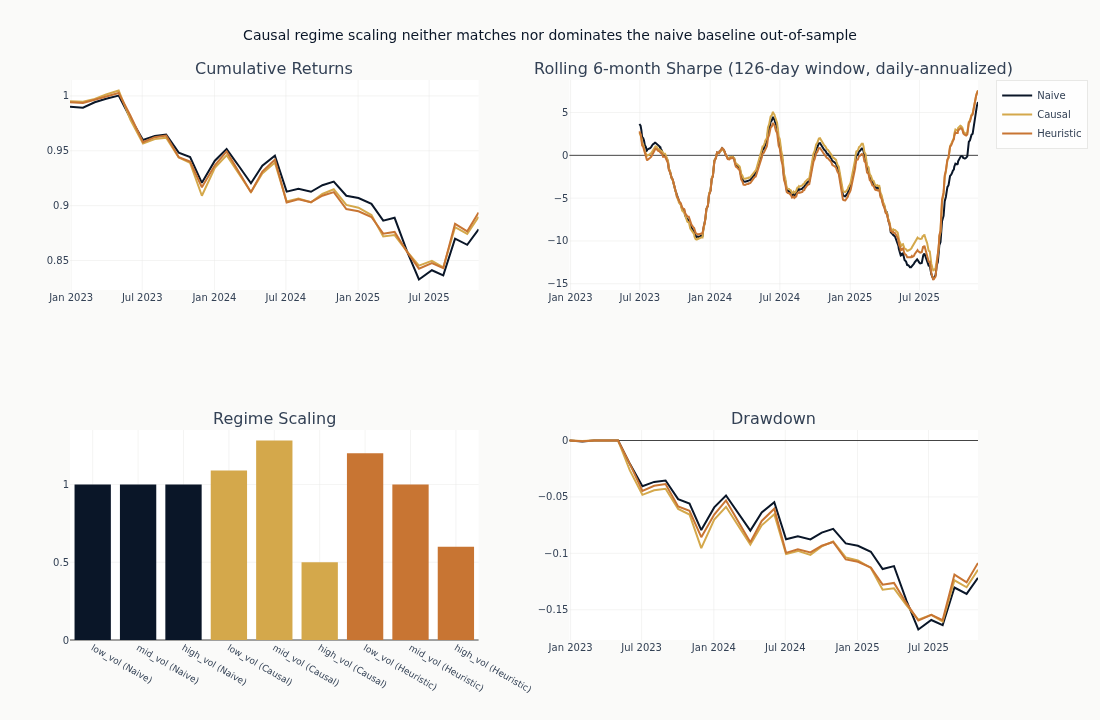

In [27]:
for col, label in [("naive", "Naive"), ("causal", "Causal"), ("heuristic", "Heuristic")]:
    cum = (1 + non_overlap[col]).cumprod()
    fig.add_trace(
        go.Scatter(
            x=non_overlap[date_col],
            y=cum / cum.cummax() - 1,
            name=label,
            line=dict(color=colors[col]),
            showlegend=False,
        ),
        row=2,
        col=2,
    )

fig.update_layout(
    title="Causal regime scaling neither matches nor dominates the naive baseline out-of-sample",
    height=720,
    width=1100,
    barmode="group",
    margin=dict(t=80, b=80, l=70, r=50),
)
# Regime-scaling x-axis labels are dense (9 categories at -45°); enforce smaller
# tick font so they don't crowd, and a tight margin so they fit.
fig.update_xaxes(tickfont=dict(size=9), row=2, col=1)
fig.show()

## 6. Honest Assessment and Key Takeaways

In [28]:
print("\n" + "=" * 60)
print("SUMMARY: HONEST ASSESSMENT")
print("=" * 60)

test_sharpes = {r["name"]: r["sharpe"] for r in results}
best_strat = max(test_sharpes, key=test_sharpes.get)
worst_strat = min(test_sharpes, key=test_sharpes.get)

print(f"""
TRAINING PERIOD FINDINGS:
  - Momentum IC: {train_ic:.4f}
  - DML reveals potential confounding from volatility regime
  - CATE estimates suggest regime-conditional effects

OUT-OF-SAMPLE REALITY CHECK:
  - Momentum IC (test): {test_ic:.4f} (vs {train_ic:.4f} train)
  - Best strategy: {best_strat} (Sharpe: {test_sharpes[best_strat]:.2f})
  - Worst strategy: {worst_strat} (Sharpe: {test_sharpes[worst_strat]:.2f})
""")


SUMMARY: HONEST ASSESSMENT

TRAINING PERIOD FINDINGS:
  - Momentum IC: 0.0226
  - DML reveals potential confounding from volatility regime
  - CATE estimates suggest regime-conditional effects

OUT-OF-SAMPLE REALITY CHECK:
  - Momentum IC (test): -0.0528 (vs 0.0226 train)
  - Best strategy: Causal (Sharpe: -0.05)
  - Worst strategy: Naive (Sharpe: -0.18)



In [29]:
print("""
KEY INSIGHTS:
  1. Causal analysis provides a rigorous framework for thinking about
     confounding, but does not guarantee out-of-sample improvement.

  2. The regime-conditional effects estimated in training may or may
     not persist - this is an empirical question, not a given.

  3. Simple heuristics (reduce exposure in high-vol) often perform
     comparably to sophisticated causal methods.

  4. Transaction costs meaningfully impact net returns - any strategy
     comparison must include them.

METHODOLOGICAL LESSONS:
  - Always use proper train/test splits for honest evaluation
  - In-sample improvements often degrade out-of-sample
  - Causal inference is about understanding mechanisms, not
    guaranteeing alpha
  - Compare to simple baselines before claiming sophistication adds value
  - Test sensitivity to transaction cost assumptions
""")


KEY INSIGHTS:
  1. Causal analysis provides a rigorous framework for thinking about
     confounding, but does not guarantee out-of-sample improvement.

  2. The regime-conditional effects estimated in training may or may
     not persist - this is an empirical question, not a given.

  3. Simple heuristics (reduce exposure in high-vol) often perform
     comparably to sophisticated causal methods.

  4. Transaction costs meaningfully impact net returns - any strategy
     comparison must include them.

METHODOLOGICAL LESSONS:
  - Always use proper train/test splits for honest evaluation
  - In-sample improvements often degrade out-of-sample
  - Causal inference is about understanding mechanisms, not
    guaranteeing alpha
  - Compare to simple baselines before claiming sophistication adds value
  - Test sensitivity to transaction cost assumptions



In [30]:
final_results = {
    "train_ic": float(train_ic),
    "test_ic": float(test_ic),
    "ate": float(ate) if ECONML_AVAILABLE and ate is not None else None,
    "cate_by_regime": (
        {k: float(v) for k, v in cate_by_regime.items()}
        if ECONML_AVAILABLE and cate_by_regime is not None
        else None
    ),
    "causal_scaling": {k: float(v) for k, v in CAUSAL_SCALING.items()},
    "test_results": {r["name"]: float(r["sharpe"]) for r in results},
    "train_results": {r["name"]: float(r["sharpe"]) for r in train_results},
}

with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2)

print(f"\nResults saved to {RESULTS_PATH}")
print(f"Test period Sharpe ratios: {final_results['test_results']}")


Results saved to /tmp/ml4t-test-output-ch15/ch15_momentum_causal_trading/momentum_causal_trading_etfs_fwd_ret_21d_full.json
Test period Sharpe ratios: {'Naive': -0.1844028142391032, 'Causal': -0.04782230435294967, 'Heuristic': -0.10901018071423402}
